<a href="https://colab.research.google.com/github/MidhunPY/Fraud_Detection_By_MachineLearning/blob/main/Fraud_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ---------- FRAUD_DETECTION_SYSTEM -------------

## **Problem Understanding:**
-------------------------
**Dataset_name** : *Credit Card Fraud Detection*

**Source**: *Kaggle*

**Problem Type**: *Binary Classification Problem*

**Target Variable**: is_fraud

**0** → Legitimate Transaction

**1** → Fraudulent Transaction *italicised text*

**Goal**: *To develop a predictive model that identifies whether a credit card transaction is fraudulent or legitimate based on transaction-related features.*

**Success_metrics**: recall,Accuracy,Precison,f-score

**Recall** → Measures how many actual frauds are correctly detected.

**Precision** → Measures how many predicted frauds are actually frauds.

**F1-Score** → Balances Precision and Recall.

**Accuracy** → Overall correctness of the model.




# **Necessary Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/credit_card_fraud_10k.csv")
df.sample(5)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
7063,7064,271.33,18,Food,0,0,59,6,37,0
7937,7938,158.42,0,Grocery,0,0,38,3,25,0
3394,3395,416.20,0,Travel,1,0,30,2,52,1
5484,5485,212.52,2,Clothing,0,0,68,1,61,0
4728,4729,244.07,3,Food,0,0,85,3,27,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [ ]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
spaced_col=[i for i in df.columns if i!=i.strip()]
spaced_col

[]

In [3]:
fraud_0=((df["is_fraud"]==0).sum()/df["is_fraud"].count())*100
fraud_1=((df["is_fraud"]==1).sum()/df["is_fraud"].count())*100

print(f"Legitimate_transaction: {fraud_0}")
print(f"Fraud_transaction: {fraud_1}")

Legitimate_transaction: 98.49
Fraud_transaction: 1.51


In [ ]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


From 5 NumberSummary : *Look like there is outlier in Amount*

## **Exploratory Data Analysis (EDA) Phase**

# 1. Univariate Analysis

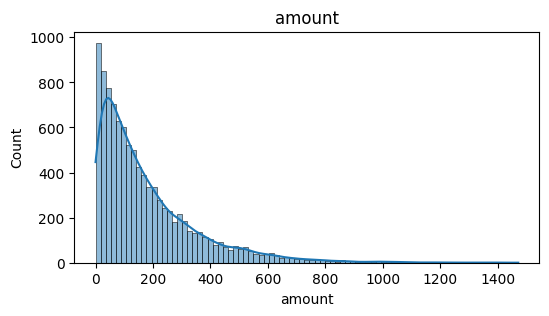

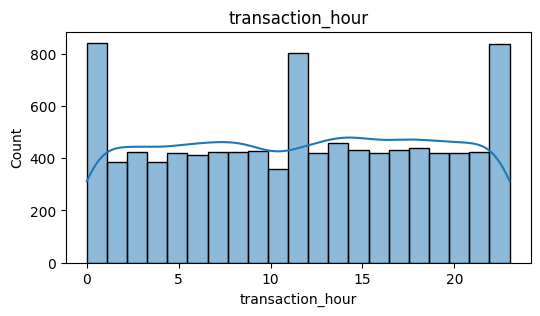

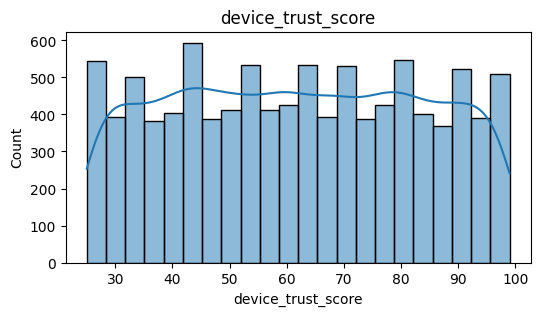

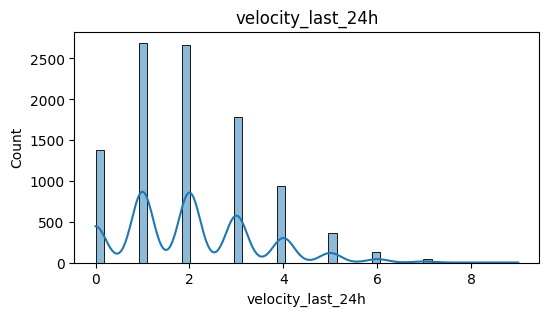

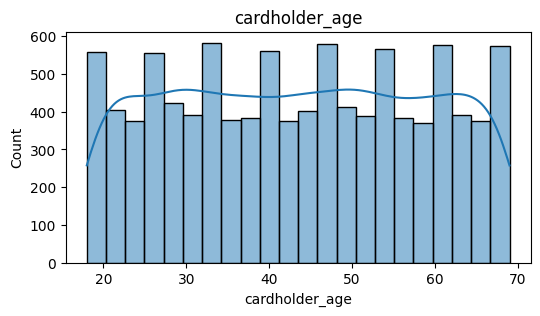

In [ ]:
num_cols = ['amount','transaction_hour',
            'device_trust_score',
            'velocity_last_24h',
            'cardholder_age']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

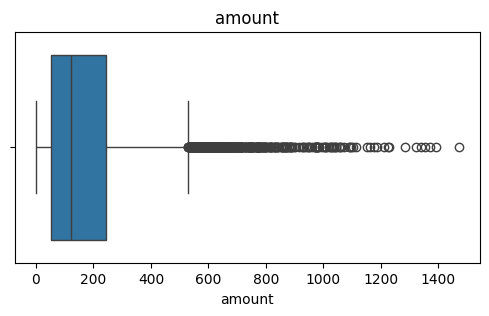

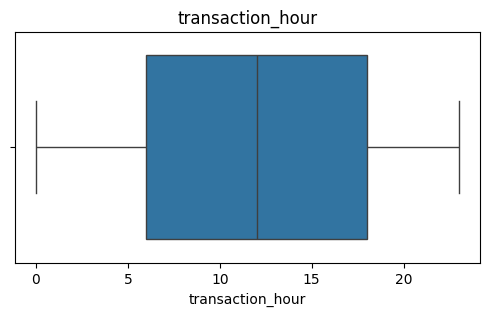

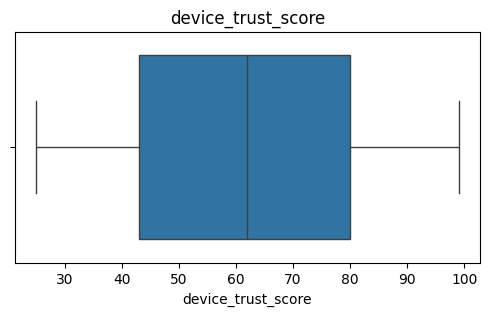

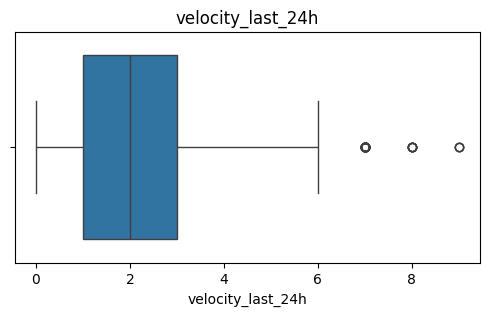

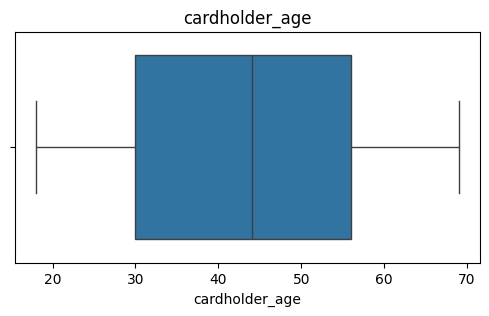

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Bivariate Analysis

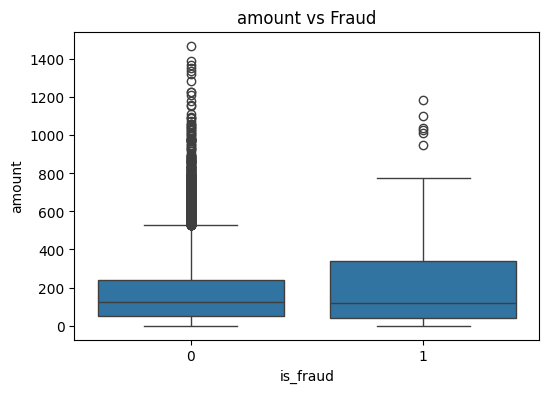

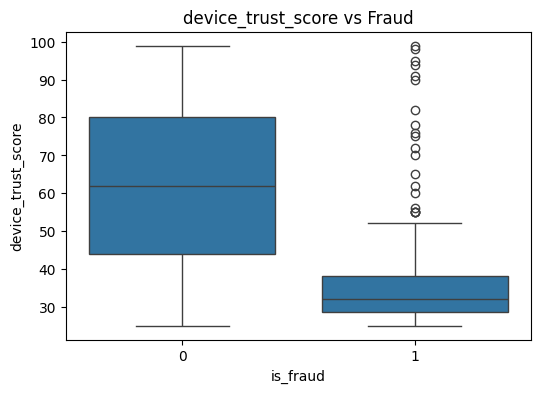

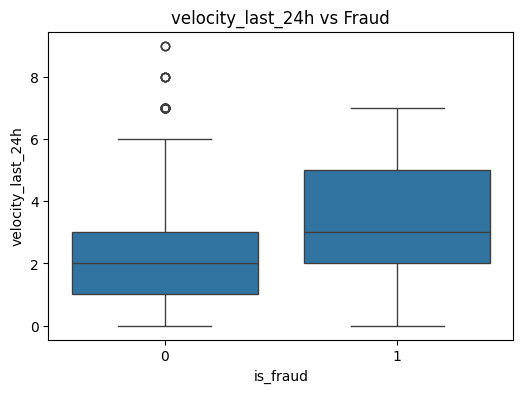

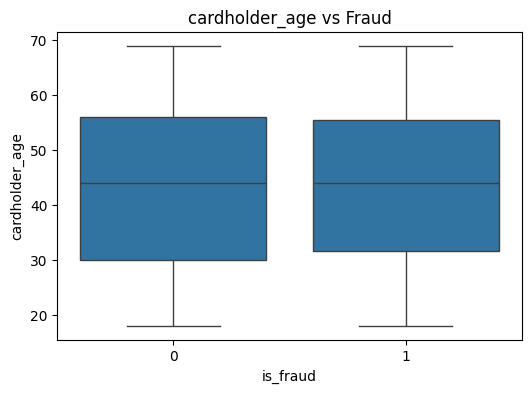

In [ ]:
num_cols = ['amount',
            'device_trust_score',
            'velocity_last_24h',
            'cardholder_age']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='is_fraud', y=col, data=df)
    plt.title(f'{col} vs Fraud')
    plt.show()

* Fraudulent transactions are more likely to occur when the device trust score is
low.

* Fraudulent Transactions generally occur at higher transaction velocities

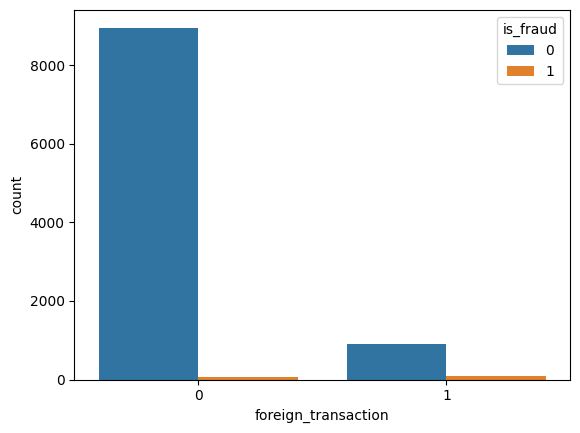

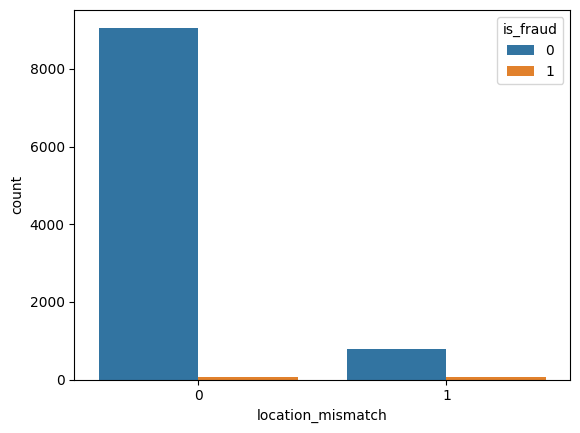

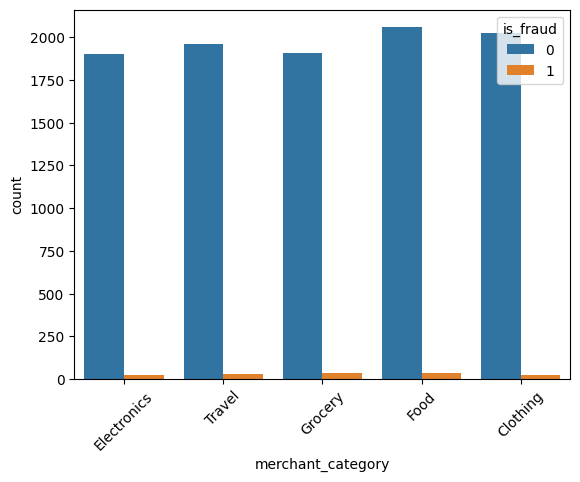

In [ ]:
sns.countplot(x='foreign_transaction',
              hue='is_fraud',
              data=df)
plt.show()

sns.countplot(x='location_mismatch',
              hue='is_fraud',
              data=df)
plt.show()

sns.countplot(x='merchant_category',
              hue='is_fraud',
              data=df)
plt.xticks(rotation=45)
plt.show()

# Multivariate Analysis

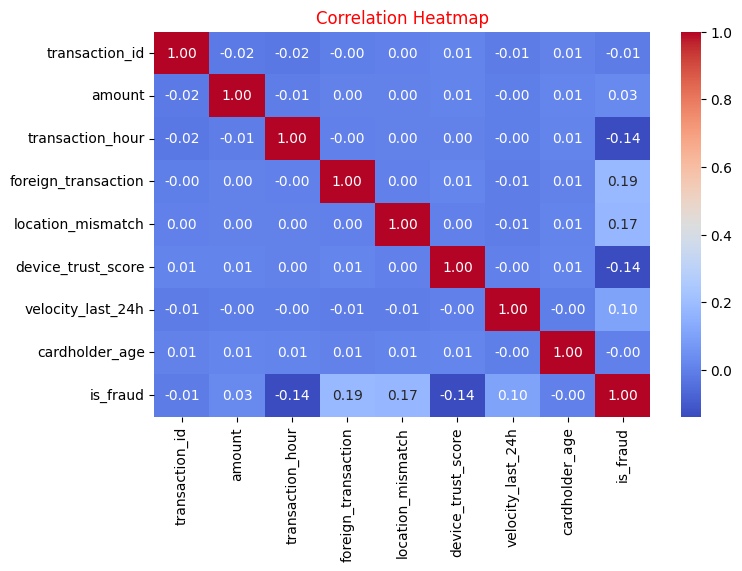

In [ ]:
corr_features=df.corr(numeric_only=True)
plt.figure(figsize=(8,5))
sns.heatmap(corr_features,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap",color="red")
plt.show()

In [4]:
df=df.drop(columns="transaction_id")
df.sample(5)

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
760,29.61,15,Grocery,0,0,82,1,46,0
1984,25.79,22,Grocery,0,0,32,4,35,0
7511,972.01,4,Electronics,0,0,62,1,54,0
9294,534.63,9,Travel,0,0,81,1,40,0
309,56.85,20,Clothing,0,0,27,4,27,0


In [5]:
fraud_rate = pd.crosstab(
    df['merchant_category'],
    df['is_fraud'],
    normalize='index'
) * 100

fraud_rate

is_fraud,0,1
merchant_category,,
Clothing,98.829268,1.170732
Electronics,98.751950,1.248050
Food,98.327759,1.672241
Grocery,97.993827,2.006173
Travel,98.542714,1.457286


*I found that fraud rates vary across merchant categories. Grocery transactions had the highest fraud rate, while Clothing had the lowest. This indicates that merchant category may contribute some predictive value, although the differences are relatively small compared to other fraud indicators.*

# Train Split Test

In [6]:
X=df.drop(columns="is_fraud")
y=df["is_fraud"]

In [ ]:
X.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
0,84.47,22,Electronics,0,0,66,3,40
1,541.82,3,Travel,1,0,87,1,64
2,237.01,17,Grocery,0,0,49,1,61
3,164.33,4,Grocery,0,1,72,3,34
4,30.53,15,Food,0,0,79,0,44


In [ ]:
y.head()

,is_fraud
0,0
1,0
2,0
3,0
4,0


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 8)
(2000, 8)
(8000,)
(2000,)


# ENCODING

In [9]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop="first", sparse_output=False,handle_unknown="ignore")
train_encoded = ohe.fit_transform(X_train[["merchant_category"]])
test_encoded = ohe.transform(X_test[["merchant_category"]])

train_encoded_df = pd.DataFrame(train_encoded, columns=ohe.get_feature_names_out(["merchant_category"]),index=X_train.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=ohe.get_feature_names_out(["merchant_category"]),index=X_test.index)

X_train = X_train.drop(columns="merchant_category")
X_test = X_test.drop(columns="merchant_category")

X_train=pd.concat([X_train,train_encoded_df],axis=1)
X_test=pd.concat([X_test,test_encoded_df],axis=1)


In [ ]:
X_train.shape


(8000, 11)

In [ ]:
X_test.shape

(2000, 11)

In [ ]:
X_train.head()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
6402,40.96,6,0,1,82,2,51,0.0,1.0,0.0,0.0
5802,57.07,6,0,0,42,2,18,1.0,0.0,0.0,0.0
4131,44.24,0,0,0,26,2,25,0.0,0.0,1.0,0.0
7626,396.80,23,0,0,97,1,34,0.0,0.0,0.0,0.0
6046,20.13,0,0,0,91,1,28,0.0,1.0,0.0,0.0


In [ ]:
X_test.head()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
9944,61.48,7,0,0,45,3,46,0.0,0.0,0.0,0.0
2601,10.06,20,0,0,25,3,26,0.0,0.0,1.0,0.0
342,34.24,5,0,0,84,1,21,1.0,0.0,0.0,0.0
3222,15.71,10,0,0,31,3,43,0.0,0.0,0.0,1.0
5216,105.84,17,0,0,26,1,21,0.0,0.0,0.0,0.0


# RobustScaling

In [10]:
from sklearn.preprocessing import RobustScaler

In [11]:
scaler=RobustScaler()
num_cols = ['amount','transaction_hour','device_trust_score','velocity_last_24h','cardholder_age']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
X_train.head()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
6402,-0.416774,-0.500000,0,1,0.555556,0.0,0.269231,0.0,1.0,0.0,0.0
5802,-0.332930,-0.500000,0,0,-0.555556,0.0,-1.000000,1.0,0.0,0.0,0.0
4131,-0.399703,-1.000000,0,0,-1.000000,0.0,-0.730769,0.0,0.0,1.0,0.0
7626,1.435185,0.916667,0,0,0.972222,-0.5,-0.384615,0.0,0.0,0.0,0.0
6046,-0.525183,-1.000000,0,0,0.805556,-0.5,-0.615385,0.0,1.0,0.0,0.0


In [ ]:
X_test.head()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
9944,-0.309978,-0.416667,0,0,-0.472222,0.5,0.076923,0.0,0.0,0.0,0.0
2601,-0.577592,0.666667,0,0,-1.027778,0.5,-0.692308,0.0,0.0,1.0,0.0
342,-0.451748,-0.583333,0,0,0.611111,-0.5,-0.884615,1.0,0.0,0.0,0.0
3222,-0.548187,-0.166667,0,0,-0.861111,0.5,-0.038462,0.0,0.0,0.0,1.0
5216,-0.079108,0.416667,0,0,-1.000000,-0.5,-0.884615,0.0,0.0,0.0,0.0


*I selected Logistic Regression as the baseline model because the target variable is binary, the dataset size is moderate, there is no severe multicollinearity among the features, and EDA showed some approximately monotonic/linear relationships with the target (e.g., lower device trust score is associated with higher fraud probability). Logistic Regression is also interpretable and provides a strong benchmark before evaluating more complex models.Yes, Random Forest can absolutely be used as a benchmark. However, I prefer Logistic Regression as the initial baseline because a baseline should ideally be simple, interpretable, and require minimal tuning. This allows me to establish a reference performance and then determine whether the additional complexity of Random Forest or boosting models provides meaningful improvement.*

# Base Model : Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

In [13]:
lr=LogisticRegression()
lr.fit(X_train,y_train)
y_predict=lr.predict(X_test)

## Evaluation

In [14]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

In [15]:
print(f"Accuract_Score: {accuracy_score(y_test,y_predict)}\n")
print(f"Confusion_Matrix: \n{confusion_matrix(y_test,y_predict)}\n")
print(f"Classification_Report: \n{classification_report(y_test,y_predict)}")

Accuract_Score: 0.9925

Confusion_Matrix: 
[[1969    1]
 [  14   16]]

Classification_Report: 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       0.94      0.53      0.68        30

    accuracy                           0.99      2000
   macro avg       0.97      0.77      0.84      2000
weighted avg       0.99      0.99      0.99      2000



## **LR + Class_Weight**

In [16]:
lr_balanced=LogisticRegression(class_weight="balanced")
lr_balanced.fit(X_train,y_train)
ypred_bal=lr_balanced.predict(X_test)

In [17]:
print(f"Accuract_Score: {accuracy_score(y_test,ypred_bal)}\n")
print(f"Confusion_Matrix: \n{confusion_matrix(y_test,ypred_bal)}\n")
print(f"Classification_Report: \n{classification_report(y_test,ypred_bal)}")

Accuract_Score: 0.957

Confusion_Matrix: 
[[1884   86]
 [   0   30]]

Classification_Report: 
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.26      1.00      0.41        30

    accuracy                           0.96      2000
   macro avg       0.63      0.98      0.69      2000
weighted avg       0.99      0.96      0.97      2000



## **LR + SMOTE**

In [18]:
from imblearn.over_sampling import SMOTE

In [19]:
smote=SMOTE(random_state=42)
smote_X,smote_y=smote.fit_resample(X_train,y_train)
print(smote_X.shape[0])
print(smote_y.shape[0])

15758
15758


In [20]:
lr_smote=LogisticRegression()
lr_smote.fit(smote_X,smote_y)
lr_smote_predict=lr_smote.predict(X_test)

In [21]:
print(f"Accuract_Score: {accuracy_score(y_test,lr_smote_predict)}\n")
print(f"Confusion_Matrix: \n{confusion_matrix(y_test,lr_smote_predict)}\n")
print(f"Classification_Report: \n{classification_report(y_test,lr_smote_predict)}")

Accuract_Score: 0.9385

Confusion_Matrix: 
[[1847  123]
 [   0   30]]

Classification_Report: 
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1970
           1       0.20      1.00      0.33        30

    accuracy                           0.94      2000
   macro avg       0.60      0.97      0.65      2000
weighted avg       0.99      0.94      0.96      2000



## RandomForest

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
rf_predict = rf.predict(X_test)

In [24]:
print(f"Accuract_Score: {accuracy_score(y_test,rf_predict)}\n")
print(f"Confusion_Matrix: \n{confusion_matrix(y_test,rf_predict)}\n")
print(f"Classification_Report: \n{classification_report(y_test,rf_predict)}")

Accuract_Score: 0.997

Confusion_Matrix: 
[[1970    0]
 [   6   24]]

Classification_Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.80      0.89        30

    accuracy                           1.00      2000
   macro avg       1.00      0.90      0.94      2000
weighted avg       1.00      1.00      1.00      2000



## RandomForest + ClassWeight

In [25]:
rf_weight = RandomForestClassifier(class_weight="balanced")
rf_weight.fit(X_train,y_train)
rf_weightpredict = rf_weight.predict(X_test)

In [26]:
print(f"Accuracy: {accuracy_score(y_test,rf_weightpredict)}\n")
print(f"Confusion_Matrix: \n{confusion_matrix(y_test,rf_weightpredict)}\n")
print(f"Classification_report:\n{classification_report(y_test,rf_weightpredict)}")

Accuracy: 0.9935

Confusion_Matrix: 
[[1970    0]
 [  13   17]]

Classification_report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.57      0.72        30

    accuracy                           0.99      2000
   macro avg       1.00      0.78      0.86      2000
weighted avg       0.99      0.99      0.99      2000



## RandomForest + Smote

In [27]:
smote=SMOTE(random_state=42)
X_train_rfsmote, y_train_rfsmote = smote.fit_resample(X_train, y_train)
print(y_train_rfsmote.value_counts())

is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [28]:
rf_smote = RandomForestClassifier()
rf_smote.fit(X_train_rfsmote,y_train_rfsmote)
rf_smote_predict = rf_smote.predict(X_test)

In [29]:
print(f"Accuracy: {accuracy_score(y_test,rf_smote_predict)}\n")
print(f"Confusion_Matrix: \n{confusion_matrix(y_test,rf_smote_predict)}\n")
print(f"Classification_report:\n{classification_report(y_test,rf_smote_predict)}")

Accuracy: 0.9925

Confusion_Matrix: 
[[1963    7]
 [   8   22]]

Classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.76      0.73      0.75        30

    accuracy                           0.99      2000
   macro avg       0.88      0.86      0.87      2000
weighted avg       0.99      0.99      0.99      2000



From this Normal RandomForestClassifier did well but f1-score is concerning

In [30]:
train_pred = rf.predict(X_train)

print(classification_report(y_train, train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7879
           1       1.00      1.00      1.00       121

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



In [31]:
test_pred = rf.predict(X_test)
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.80      0.89        30

    accuracy                           1.00      2000
   macro avg       1.00      0.90      0.94      2000
weighted avg       1.00      1.00      1.00      2000



## Cross-validation

In [32]:
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print(rf_scores)
print("Mean F1:", rf_scores.mean())

[0.62857143 0.7027027  0.8        0.73684211 0.75      ]
Mean F1: 0.7236232473074579


## XGBOOST

In [33]:
from xgboost import XGBClassifier

In [34]:
xgb = XGBClassifier(random_state=42 , eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_predict = xgb.predict(X_test)

In [35]:
print(f"Accuracy: {accuracy_score(y_test,xgb_predict)}\n")
print(f"Confusion_Matrix: \n{confusion_matrix(y_test,xgb_predict)}\n")
print(f"Classification_report:\n{classification_report(y_test,xgb_predict)}")

Accuracy: 1.0

Confusion_Matrix: 
[[1970    0]
 [   0   30]]

Classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## Checking Dataleakage

In [36]:
print(X_train.columns)

Index(['amount', 'transaction_hour', 'foreign_transaction',
       'location_mismatch', 'device_trust_score', 'velocity_last_24h',
       'cardholder_age', 'merchant_category_Electronics',
       'merchant_category_Food', 'merchant_category_Grocery',
       'merchant_category_Travel'],
      dtype='object')


In [37]:
train_pred = xgb.predict(X_train)

print(classification_report(y_train, train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7879
           1       1.00      1.00      1.00       121

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



In [38]:
test_pred = xgb.predict(X_test)
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## **Cross Validation**

In [39]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print(scores)
print(scores.mean())

[0.9787234  0.88372093 0.9787234  0.9787234  0.95833333]
0.9556448952663696


## CROSS VALIDATION

## Hyperparameter Tunning

In [45]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


In [46]:
xgb_tuning = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid = {
    "n_estimators":[100,200,300,500],
    "max_depth":[2,3,5,7],
    "learning_rate":[0.01,0.1,0.2],
    "subsample":[0.8,1.0],
    "colsample_bytree":[0.8,1.0]
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_tuning,
    param_distributions=param_grid,
    n_iter=10,
    scoring="f1",
    cv=skf,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

best_xgb = random_search.best_estimator_

y_predict_best = best_xgb.predict(X_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV F1: 0.9875677930746767


In [48]:
print(f"Accuracy: {accuracy_score(y_test,y_predict_best)}\n")
print(f"Confusion_Matrix: \n{confusion_matrix(y_test,y_predict_best)}\n")
print(f"Classification_report:\n{classification_report(y_test,y_predict_best)}")

Accuracy: 1.0

Confusion_Matrix: 
[[1970    0]
 [   0   30]]

Classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## **RESULTS**

| Model                              | Accuracy | Precision (Fraud) | Recall (Fraud) | F1-Score (Fraud) | Notes                             |
| ---------------------------------- | -------- | ----------------- | -------------- | ---------------- | --------------------------------- |
| Logistic Regression                | 0.9925   | 0.94              | 0.53           | 0.68             | Baseline model                    |
| Logistic Regression + Class Weight | 0.9570   | 0.26              | 1.00           | 0.41             | High recall, many false positives |
| Logistic Regression + SMOTE        | 0.9385   | 0.20              | 1.00           | 0.33             | Performance degraded              |
| Random Forest                      | 0.9970   | 1.00              | 0.80           | 0.89             | Best RF model                     |
| Random Forest + Class Weight       | 0.9935   | 1.00              | 0.57           | 0.72             | Worse than RF                     |
| Random Forest + SMOTE              | 0.9930   | 0.79              | 0.73           | 0.76             | Worse than RF                     |
| XGBoost                            | 1.0000   | 1.00              | 1.00           | 1.00             | Best hold-out test performance    |


| Model                                | Mean CV F1 |
| -------------   | ---------- |
| Random Forest   | 0.715      |
| XGBoost          | 0.956      |
| XGBoost-Tunned        | 0.99     |
